In [1]:
# !pip install pytorchvideo transformers evaluate -q
# !pip install pytorchvideo torchvision==0.12.0
# !pip install evaluate

In [2]:
# pip install opencv-python


In [3]:
# !pip install --upgrade torch

In [4]:
# conda env list

In [ ]:
# #model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
# #model_ckpt = "google/vivit-b-16x2-kinetics400"
# model_ckpt="facebook/timesformer-base-finetuned-k400"
# batch_size = 4 # batch size for training and evaluation
# from transformers import VideoMAEConfig, VideoMAEModel

# # Initializing a VideoMAE videomae-base style configuration
# configuration = VideoMAEConfig()

# # Randomly initializing a model from the configuration
# model = VideoMAEModel(configuration)

# # Accessing the model configuration
# configuration = model.config
# print(configuration)

In [ ]:
# #model_ckpt="facebook/timesformer-base-finetuned-k400"
# #model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
# model_ckpt = "google/vivit-b-16x2-kinetics400"
# batch_size = 4 # batch size for training and evaluation
# from transformers import TimesformerConfig, TimesformerModel

# # Initializing a TimeSformer timesformer-base style configuration
# configuration = TimesformerConfig()

# # Initializing a model from the configuration
# model = TimesformerModel(configuration)

# # Accessing the model configuration
# configuration = model.config
# print(configuration)


In [ ]:
model_ckpt = "google/vivit-b-16x2-kinetics400"
batch_size = 4
from transformers import VivitConfig, VivitModel

# Initializing a ViViT google/vivit-b-16x2-kinetics400 style configuration
configuration = VivitConfig()

# Initializing a model (with random weights) from the google/vivit-b-16x2-kinetics400 style configuration
model = VivitModel(configuration)

# Accessing the model configuration
configuration = model.config

print(configuration)

In [3]:
import pathlib

# Specify the dataset root path (make sure to define it beforehand)
#dataset_root_path = pathlib.Path('/kaggle/input/bdslw60-all-u1-u4-and-u8/BdSLW60_ALL')  # Change to your actual path
output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/15% split train-val frame rate corrected')
# Count videos in each set
video_count_train = len(list(output_root_path.glob("train/*/*.mp4")))
video_count_val = len(list(output_root_path.glob("val/*/*.mp4")))
video_count_test = len(list(output_root_path.glob("test/*/*.mp4")))

# Calculate total videos
video_total = video_count_train + video_count_val + video_count_test
print(f"Total videos: {video_total}")

# List all video file paths
all_video_file_paths = (
    list(output_root_path.glob("train/*/*.mp4")) +
    list(output_root_path.glob("val/*/*.mp4")) +
    list(output_root_path.glob("test/*/*.mp4"))
)

# Display the first five video file paths
print(all_video_file_paths[:5])

# Print total number of videos in each set and the first 5 video file paths for training
print(f"Total videos: {video_total}")
print(f"Training videos: {video_count_train}, Validation videos: {video_count_val}, Test videos: {video_count_test}")


Total videos: 9307
[PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/15% split train-val frame rate corrected/train/cake/U5W44F_trial_6_R.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/15% split train-val frame rate corrected/train/cake/U3W44F_trial_12_R.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/15% split train-val frame rate corrected/train/cake/U13W44F_trial_0_L.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/15% split train-val frame rate corrected/train/cake/U13W44F_trial_1_L.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/15% split train-val frame rate corrected/train/cake/U12W44F_trial_5_R.mp4')]
Total videos: 9307
Training videos: 7181, Validation videos: 850, Test videos: 1276


In [4]:
# Adjust class label extraction logic
class_labels = sorted({str(path.parent.name) for path in all_video_file_paths})  # Use parent folder name as class label
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}
# Print the unique class labels and their mappings
print(f"Unique classes: {list(label2id.keys())}.")
print(f"Label to ID mapping: {label2id}")
#print(f"ID to Label mapping: {id2label}")

Unique classes: ['aam', 'aaple', 'ac', 'aids', 'alu', 'anaros', 'angur', 'apartment', 'attio', 'audio cassette', 'ayna', 'baandej', 'baat', 'baba', 'balti', 'balu', 'bhai', 'biscuts', 'bon', 'boroi', 'bottam', 'bou', 'cake', 'capsule', 'cha', 'chacha', 'chachi', 'chadar', 'chal', 'chikissha', 'chini', 'chips', 'chiruni', 'chocolate', 'chokh utha', 'chosma', 'churi', 'clip', 'cream', 'dada', 'dadi', 'daeitto', 'dal', 'debor', 'denadar', 'dengue', 'doctor', 'dongson', 'dulavai', 'durbol', 'jomoj', 'juta', 'konna', 'maa', 'tattha', 'toothpaste', 'tshirt', 'tubelight', 'tupi', 'tv'].
Label to ID mapping: {'aam': 0, 'aaple': 1, 'ac': 2, 'aids': 3, 'alu': 4, 'anaros': 5, 'angur': 6, 'apartment': 7, 'attio': 8, 'audio cassette': 9, 'ayna': 10, 'baandej': 11, 'baat': 12, 'baba': 13, 'balti': 14, 'balu': 15, 'bhai': 16, 'biscuts': 17, 'bon': 18, 'boroi': 19, 'bottam': 20, 'bou': 21, 'cake': 22, 'capsule': 23, 'cha': 24, 'chacha': 25, 'chachi': 26, 'chadar': 27, 'chal': 28, 'chikissha': 29, 'chi

In [5]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from transformers import VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification

image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
model = VivitForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)

"""image_processor = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
model = TimesformerForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,)"""

"""image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)"""
import pytorchvideo.data

from pytorchvideo.transforms import (
    ApplyTransformToKey,
    Normalize,
    RandomShortSideScale,
    RemoveKey,
    ShortSideScale,
    UniformTemporalSubsample,
)

from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    Resize,
)

/home/cse/.local/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/cse/.local/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warn(f"Failed to load image Python extension: {e}")
2024-11-13 19:05:43.040926: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-13 19:05:43.178173: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-13 19:05:43.178212: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been

In [6]:
import os
import os
import cv2  # Import OpenCV to handle video files
from pytorchvideo.data import make_clip_sampler, Ucf101
from torchvision.transforms import Compose
from transformers import VideoMAEForVideoClassification, VideoMAEConfig
from transformers import VivitConfig, VivitModel, VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification


# Load the model configuration
#model_ckpt = "MCG-NJU/videomae-base"
#model_ckpt = "facebook/timesformer-base-finetuned-k400"
#config = TimesformerForVideoClassification.from_pretrained(model_ckpt)
#config = VideoMAEConfig.from_pretrained(model_ckpt)
model_ckpt = "google/vivit-b-16x2-kinetics400"
config = VivitForVideoClassification.from_pretrained(model_ckpt)
#num_frames_to_sample = config.num_frames


mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)

num_frames_to_sample = model.config.num_frames
print(f"Number of frames to sample: {num_frames_to_sample}")
sample_rate = 4 # vivit
fps = 30
clip_duration = num_frames_to_sample * sample_rate / fps

# Training dataset transformations.
train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                    RandomShortSideScale(min_size=256, max_size=320),
                    RandomCrop(resize_to),
                    
                    RandomHorizontalFlip(p=0.5),
                    
                ]
            ),
        ),
    ]
)

# Training dataset.
train_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "train"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("random", clip_duration),
    decode_audio=False,
    transform=train_transform,
)



# Validation and evaluation datasets' transformations.
val_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                ]
            ),
        ),
    ]
)

# Validation and evaluation datasets.
val_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "val"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

test_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "test"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

Number of frames to sample: 32


In [7]:
train_dataset.num_videos, val_dataset.num_videos, test_dataset.num_videos

(7181, 850, 1276)

In [8]:
# train data sample
sample_video = next(iter(train_dataset))
sample_video.keys()

dict_keys(['video', 'video_name', 'video_index', 'clip_index', 'aug_index', 'label'])

In [9]:
def investigate_video(sample_video):
    """Utility to investigate the keys present in a single video sample."""
    for k in sample_video:
        if k == "video":
            print(k, sample_video["video"].shape)
        else:
            print(k, sample_video[k])

    print(f"Video label: {id2label[sample_video[k]]}")

investigate_video(sample_video)

video torch.Size([3, 32, 224, 224])
video_name U2W3F_trial_9_R.mp4
video_index 2019
clip_index 0
aug_index 0
label 16
Video label: bhai


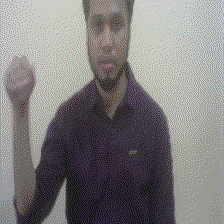

In [10]:
import imageio
import numpy as np
from IPython.display import Image


def unnormalize_img(img):
    """Un-normalizes the image pixels."""
    img = (img * std) + mean
    img = (img * 255).astype("uint8")
    return img.clip(0, 255)


def create_gif(video_tensor, filename="sample.gif"):
    """Prepares a GIF from a video tensor.
    
    The video tensor is expected to have the following shape:
    (num_frames, num_channels, height, width).
    """
    frames = []
    for video_frame in video_tensor:
        frame_unnormalized = unnormalize_img(video_frame.permute(1, 2, 0).numpy())
        frames.append(frame_unnormalized)
    kargs = {"duration": 0.25}
    imageio.mimsave(filename, frames, "GIF", **kargs)
    return filename


def display_gif(video_tensor, gif_name="sample.gif"):
    """Prepares and displays a GIF from a video tensor."""
    video_tensor = video_tensor.permute(1, 0, 2, 3)
    gif_filename = create_gif(video_tensor, gif_name)
    return Image(filename=gif_filename)

video_tensor = sample_video["video"]
display_gif(video_tensor)
#print(video_tensor.shape)

In [11]:
import evaluate
metric = evaluate.load("accuracy")
import torch

def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions."""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)


def collate_fn(examples):
    """The collation function to be used by `Trainer` to prepare data batches."""
    # permute to (num_frames, num_channels, height, width)
    pixel_values = torch.stack(
        [example["video"].permute(1, 0, 2, 3) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
from huggingface_hub import login, hf_hub_download
# RnW token

# Authenticate using the API token
login(token=hf_token)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to /home/cse/.cache/huggingface/token
Login successful


In [ ]:
import os
import torch
import logging
import matplotlib.pyplot as plt
import numpy as np
from transformers import Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
from transformers import EarlyStoppingCallback, AutoImageProcessor, VideoMAEForVideoClassification, VideoMAEImageProcessor
import seaborn as sns
import evaluate

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

num_epochs = 20

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model and image processor
# model_ckpt = "MCG-NJU/videomae-base"
# image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
# model = VideoMAEForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# )
model_ckpt = "google/vivit-b-16x2-kinetics400"
image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")  
model = VivitForVideoClassification.from_pretrained(
model_ckpt,
label2id=label2id,
id2label=id2label,
ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
) 
model.to(device)

# Output directory for checkpoints
output_checkpoint_dir = r"/media/cse/HDD/Shawon/shawon/MY DATA/ViViT_BdSLW60_FrameRate_NOT_Corrected_with_Augment_20_epoch_val_U5_codeChecking"
os.makedirs(output_checkpoint_dir, exist_ok=True)

# Plot confusion matrix
def plot_confusion_matrix(conf_matrix, class_labels, accuracy=None, dataset_name="Test Data", normalize=False, filename="confusion_matrix.png"):
    if normalize:
        conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(conf_matrix, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", 
                xticklabels=class_labels, yticklabels=class_labels)
    
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    
    title = f"ViViT_BdSLW60 | {dataset_name} | Accuracy = {accuracy:.6f}" if accuracy is not None else f"ViViT_BdSLW60 | {dataset_name}"
    plt.title(title)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()

# Compute metrics function
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    # Calculate metrics
    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted',zero_division=0)
    # Log metrics
    logging.info(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, Accuracy: {accuracy:.4f}")
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Training arguments
#batch_size = 32
args = TrainingArguments(
    output_dir=output_checkpoint_dir,
    remove_unused_columns=False,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    warmup_ratio=0.1,
    logging_steps=100,
    metric_for_best_model="accuracy",
    push_to_hub=True,
    load_best_model_at_end=True,
    max_steps=(train_dataset.num_videos // (1*4)) * num_epochs,  # Dynamically calculate max_steps
    report_to="none",
    fp16=True,
    weight_decay=0.01,
)

# Trainer initialization
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

# Train the model
trainer.train()
trainer.save_model()

# ------------------- TRAINING METRICS -------------------
train_predictions = trainer.predict(train_dataset)
train_preds = np.argmax(train_predictions.predictions, axis=1)
train_labels = train_predictions.label_ids

train_accuracy = accuracy_score(train_labels, train_preds)
train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(train_labels, train_preds, average='weighted')

logging.info(f"Training Metrics - Accuracy: {train_accuracy:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")

plot_confusion_matrix(
    conf_matrix=confusion_matrix(train_labels, train_preds), 
    class_labels=list(id2label.values()), 
    accuracy=train_accuracy, 
    dataset_name=f"Train Data | P: {train_precision:.3f}, R: {train_recall:.3f}, F1: {train_f1:.3f}",
    filename="confusion_matrix_train600.png"
)

# ------------------- VALIDATION METRICS -------------------
val_predictions = trainer.predict(val_dataset)
val_preds = np.argmax(val_predictions.predictions, axis=1)
val_labels = val_predictions.label_ids

val_accuracy = accuracy_score(val_labels, val_preds)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='weighted')

logging.info(f"Validation Metrics - Accuracy: {val_accuracy:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")

plot_confusion_matrix(
    conf_matrix=confusion_matrix(val_labels, val_preds), 
    class_labels=list(id2label.values()), 
    accuracy=val_accuracy, 
    dataset_name=f"Valid Data | P: {val_precision:.3f}, R: {val_recall:.3f}, F1: {val_f1:.3f}",
    filename="confusion_matrix_valid600.png"
)

# ------------------- TEST METRICS -------------------
test_predictions = trainer.predict(test_dataset)
test_preds = np.argmax(test_predictions.predictions, axis=1)
test_labels = test_predictions.label_ids

test_accuracy = accuracy_score(test_labels, test_preds)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='weighted')

logging.info(f"Test Metrics - Accuracy: {test_accuracy:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1: {test_f1:.4f}")

plot_confusion_matrix(
    conf_matrix=confusion_matrix(test_labels, test_preds), 
    class_labels=list(id2label.values()), 
    accuracy=test_accuracy, 
    dataset_name=f"Test Data | P: {test_precision:.3f}, R: {test_recall:.3f}, F1: {test_f1:.3f}",
    filename="confusion_matrix_test600.png"
)

# Calculate metrics for the test dataset
test_results = {
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
}

# Log and save metrics
trainer.log_metrics("test", test_results)
trainer.save_metrics("test", test_results)
trainer.save_state()
trainer.push_to_hub()

logging.info(f"Training complete. Model and checkpoints saved in: {output_checkpoint_dir}")
print(f"Training complete. Model and checkpoints saved in: {output_checkpoint_dir}")
